In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv('placement (2).csv')

In [4]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: xlabel='placement_exam_marks', ylabel='Count'>

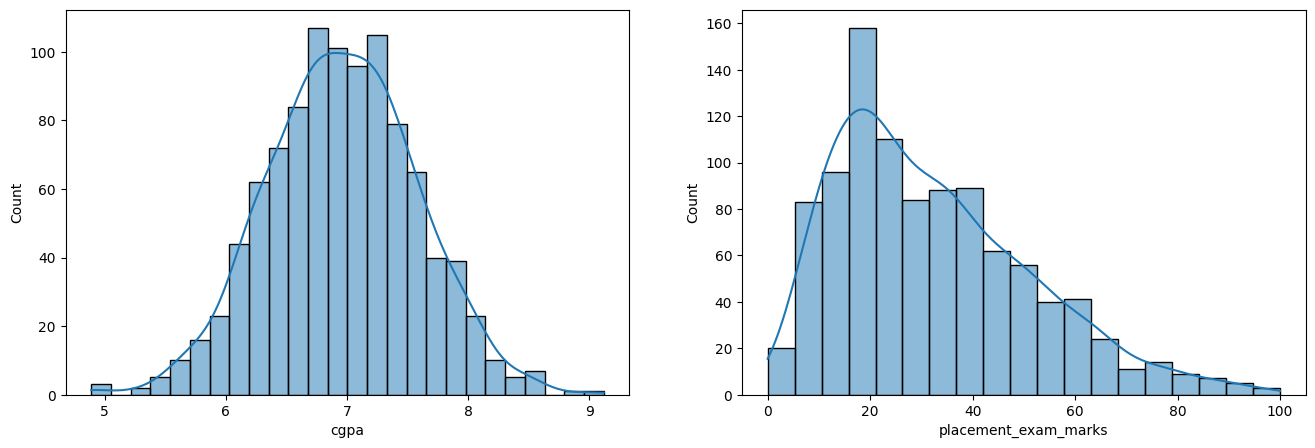

In [5]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.histplot(df['cgpa'], kde=True)

plt.subplot(122)
sns.histplot(df['placement_exam_marks'], kde=True)

In [6]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

In [7]:
df['cgpa'].describe()

count    1000.000000
mean        6.961240
std         0.615898
min         4.890000
25%         6.550000
50%         6.960000
75%         7.370000
max         9.120000
Name: cgpa, dtype: float64

<Axes: ylabel='placement_exam_marks'>

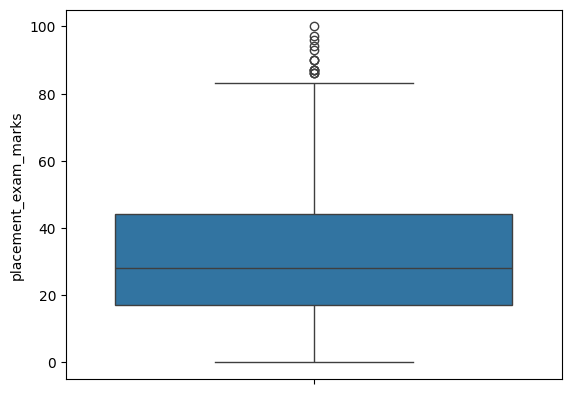

In [8]:
sns.boxplot(df['placement_exam_marks'])

In [9]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [10]:
percentile25, percentile75

(np.float64(17.0), np.float64(44.0))

In [11]:
iqr = percentile75 - percentile25

In [12]:
iqr

np.float64(27.0)

In [13]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

# finding outliers

In [14]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


# Trimming

In [15]:
new_df = df[df['placement_exam_marks'] <= upper_limit]

In [16]:
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


<Axes: ylabel='placement_exam_marks'>

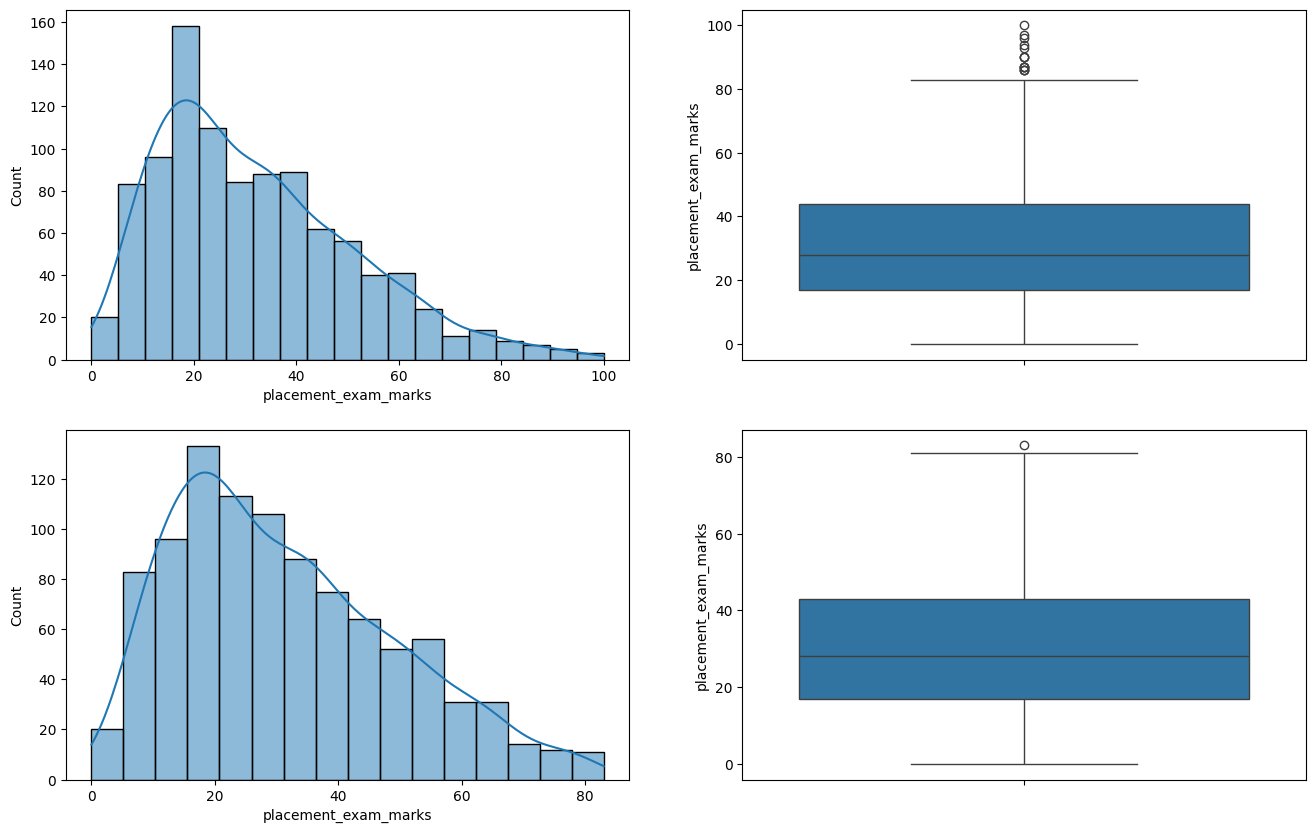

In [19]:
#comparing
plt.figure(figsize=(16,10))
plt.subplot(221)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.subplot(222)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(223)
sns.histplot(new_df['placement_exam_marks'], kde=True)
plt.subplot(224)
sns.boxplot(new_df['placement_exam_marks'])


# capping

In [22]:
new_df_cap  = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
      upper_limit, 
      np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
      
      new_df_cap['placement_exam_marks']
    )
)

In [23]:
new_df_cap.shape

(1000, 3)

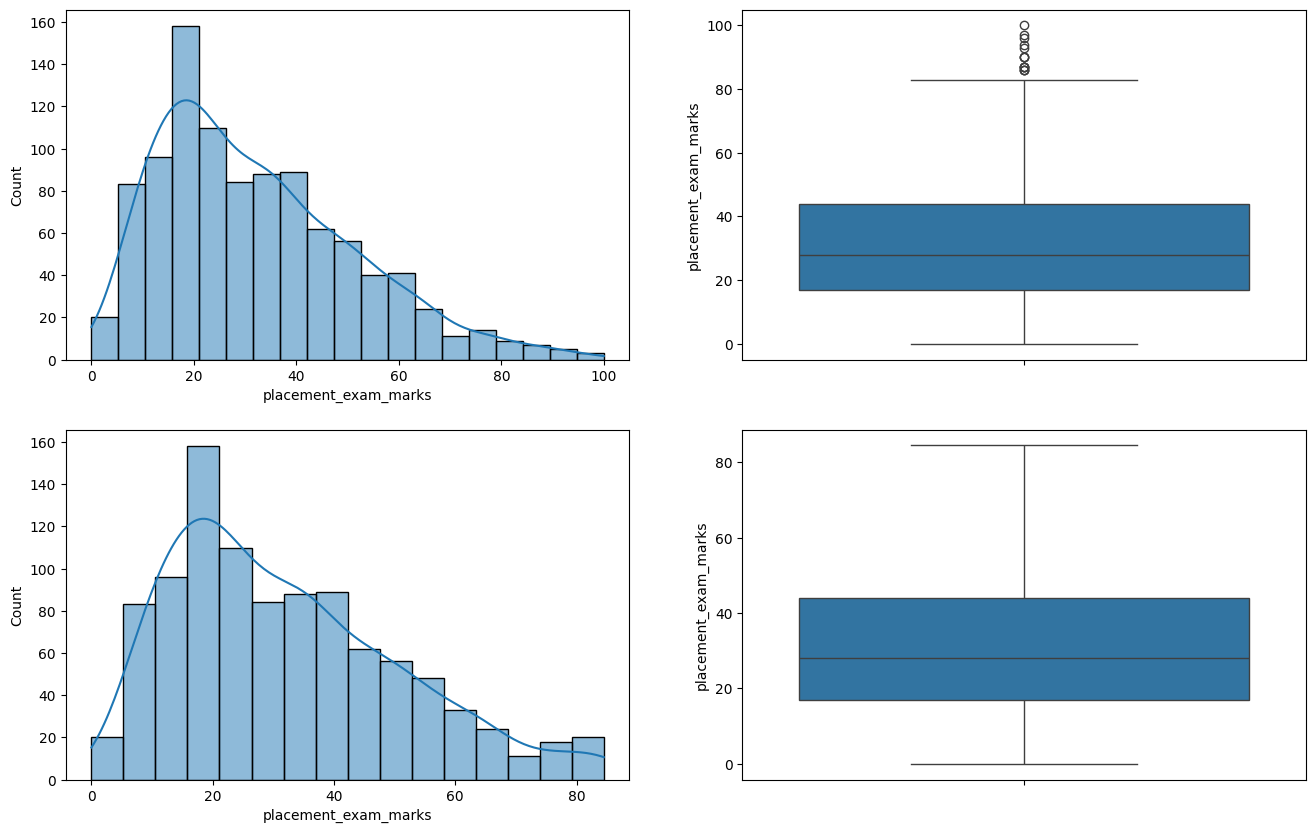

In [26]:

# Comparing

plt.figure(figsize=(16,10))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df_cap['placement_exam_marks'],kde=True)

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])

plt.show()